Train Notebook for my ALU Final Year Mission Capstone Project
**bold text**

Author: Best Verie Iradukunda

1. Requirements Setup

In [9]:
!pip -q install pandas numpy networkx scikit-learn imbalanced-learn xgboost shap matplotlib openpyxl node2vec

import warnings, re
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
print("ready")

ready


Data preparation & cleaning

In [10]:
import os
BRANCHES = ["Gasabo", "Kicukiro", "Nyarugenge"]
paths = {}
for b in BRANCHES:
    for p in (f"{b}.xlsx", f"data/{b}.xlsx"):
        if os.path.exists(p): paths[b] = p; break
if len(paths) < len(BRANCHES):
    from google.colab import files
    up = files.upload()
    for fn in up:
        for b in BRANCHES:
            if b.lower() in fn.lower(): paths[b] = fn
print("files:", paths)

files: {'Gasabo': 'Gasabo.xlsx', 'Kicukiro': 'Kicukiro.xlsx', 'Nyarugenge': 'Nyarugenge.xlsx'}


In [11]:
num = lambda s: int(re.search(r"(\d+)$", str(s)).group(1))
ARREARS_BAD = 90        # an ACTIVE loan this many+ days in arrears is counted as "bad" (at risk)

frames = []
for b, path in paths.items():
    xl = pd.ExcelFile(path)
    wo = xl.parse("Written Off Loans").assign(_sheet="Written Off")
    nm = xl.parse("Normal Loans").assign(_sheet="Normal")
    df = pd.concat([wo, nm], ignore_index=True); df["branch"] = b; frames.append(df)
raw = pd.concat(frames, ignore_index=True)

for c in ["Date Guaranteed","Customer Opening Date","Disbursement Date","Last Payment Date"]:
    raw[c] = pd.to_datetime(raw[c], errors="coerce")
for c in ["Savings","Salary","Disbursement Amount","Interest Rate","Days in Arrears"]:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")

# LABEL: written off OR (active AND 90+ days in arrears) = bad. Uses Payment Status if present.
if "Payment Status" in raw.columns:
    status = raw["Payment Status"].astype(str).str.strip().str.lower()
    active_bad = (status == "active") & (raw["Days in Arrears"].fillna(0) >= ARREARS_BAD)
    raw["label"] = ((raw["_sheet"] == "Written Off") | active_bad).astype(int)
    raw["outcome"] = np.where(raw["label"] == 1, "Default / at risk", "Performing")
    print(f"Payment Status found -> active loans {ARREARS_BAD}+ days in arrears counted as bad.")
else:
    raw["label"] = (raw["_sheet"] == "Written Off").astype(int)
    raw["outcome"] = np.where(raw["label"] == 1, "Written Off", "Repaid")
    print("No Payment Status column -> label = Written Off vs Normal.")

# IDs reset per branch -> namespace so a member is unique across branches
raw["member"]   = raw["branch"] + "-" + raw["Borrower ID"].map(num).astype(str)
raw["g_member"] = raw["branch"] + "-" + raw["Guarantor ID"].map(num).astype(str)
raw["loan_key"] = raw["branch"] + "-" + raw["Loan ID"].astype(str)
print("pair-rows:", raw.shape)
raw.head(3)

Payment Status found -> active loans 90+ days in arrears counted as bad.
pair-rows: (10180, 24)


,Loan ID,Borrower ID,Guarantor ID,Date Guaranteed,Customer Opening Date,Disbursement Amount,Disbursement Date,Last Payment Date,Interest Rate,Non Paid Capital,...,Savings,Salary,Payment Status,_sheet,branch,label,outcome,member,g_member,loan_key
0,Loan0001,Client335,Client189,2023-02-21,2009-09-30,1323000,2023-02-21,2024-10-21,16,0,...,32036,91617,Written Off,Written Off,Gasabo,1,Default / at risk,Gasabo-335,Gasabo-189,Gasabo-Loan0001
1,Loan0001,Client335,Client664,2023-02-21,2009-09-30,1323000,2023-02-21,2024-10-21,16,0,...,32036,91617,Written Off,Written Off,Gasabo,1,Default / at risk,Gasabo-335,Gasabo-664,Gasabo-Loan0001
2,Loan0001,Client335,Client366,2023-02-21,2009-09-30,1323000,2023-02-21,2024-10-21,16,0,...,32036,91617,Written Off,Written Off,Gasabo,1,Default / at risk,Gasabo-335,Gasabo-366,Gasabo-Loan0001


In [12]:
# collapse to one row per loan
loans = (raw.groupby("loan_key").agg(
            branch=("branch","first"), member=("member","first"), label=("label","first"),
            amount=("Disbursement Amount","first"), disb=("Disbursement Date","first"),
            opened=("Customer Opening Date","first"), last_pay=("Last Payment Date","first"),
            rate=("Interest Rate","first"), savings=("Savings","first"), salary=("Salary","first"),
            guarantors=("g_member", list)).reset_index())
loans["n_g"] = loans["guarantors"].map(len)
print(f"{len(loans)} loans | {int(loans.label.sum())} flagged bad ({100*loans.label.mean():.1f}%)")
# selection-bias check: bad loans by disbursement year (active+arrears bring back recent years)
yb = loans.assign(yr=loans["disb"].dt.year).groupby("yr")["label"].sum().astype(int)
print("\nbad loans by disbursement year (recent years should NOT be empty):")
print(yb[yb > 0].to_string())
print("\nmissing values per column:"); print(loans[["amount","disb","opened","rate","savings","salary"]].isna().sum())
loans.describe(include="all").T.head(12)

3600 loans | 768 flagged bad (21.3%)

bad loans by disbursement year (recent years should NOT be empty):
yr
2019    103
2020    127
2021    128
2022     90
2023    114
2024    119
2025     87

missing values per column:
amount     0
disb       0
opened     0
rate       0
savings    0
salary     0
dtype: int64


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
loan_key,3600,3600,Nyarugenge-Loan1184,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
branch,3600,3,Gasabo,1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member,3600,1712,Nyarugenge-246,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,3600.0,NaN,NaN,NaN,0.213333,0.0,0.0,0.0,0.0,1.0,0.409718
amount,3600.0,NaN,NaN,NaN,1835072.777778,262000.0,1146750.0,1629500.0,2269250.0,9826000.0,982113.899064
disb,3600,NaN,NaN,NaN,2022-06-25 05:50:48,2019-01-02 00:00:00,2020-10-17 18:00:00,2022-07-09 12:00:00,2024-03-13 00:00:00,2025-11-25 00:00:00,NaN
opened,3600,NaN,NaN,NaN,2012-06-19 19:23:36.000000256,2007-07-07 00:00:00,2010-01-14 00:00:00,2012-06-13 00:00:00,2015-01-04 00:00:00,2017-06-30 00:00:00,NaN
last_pay,3600,NaN,NaN,NaN,2024-02-26 12:35:36,2020-01-05 00:00:00,2022-10-22 18:00:00,2024-06-09 12:00:00,2025-09-29 00:00:00,2025-12-31 00:00:00,NaN
rate,3600.0,NaN,NaN,NaN,13.788611,13.0,13.0,13.0,14.0,16.0,1.164222
savings,3600.0,NaN,NaN,NaN,337335.805278,15207.0,139636.0,244931.0,434362.0,2505546.0,310277.919957


Exploratory Data Analysis

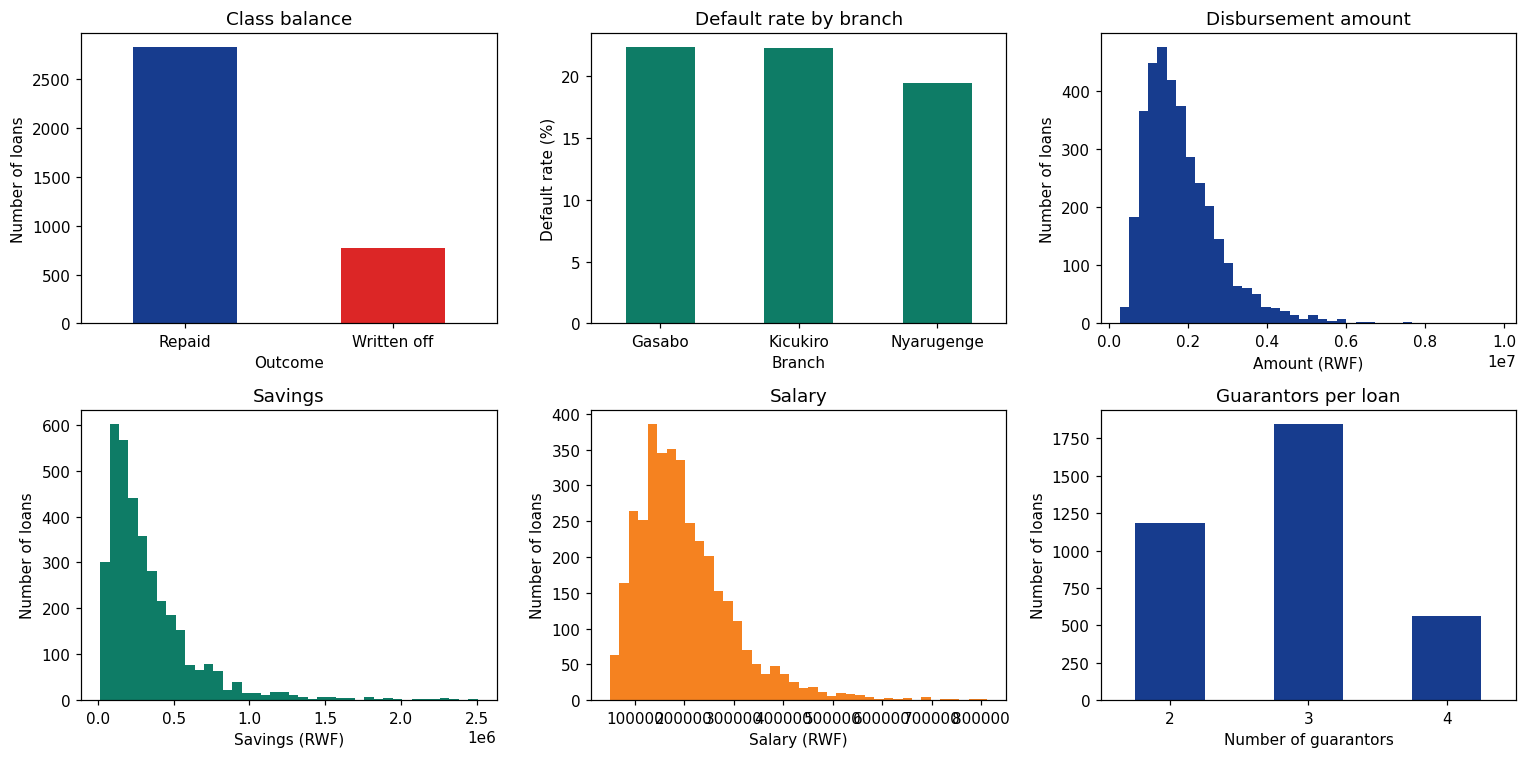

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
loans["label"].map({0:"Repaid",1:"Written off"}).value_counts().plot.bar(ax=ax[0,0], color=["#173C8E","#DC2626"])
ax[0,0].set_title("Class balance"); ax[0,0].set_xlabel("Outcome"); ax[0,0].set_ylabel("Number of loans"); ax[0,0].tick_params(axis="x", rotation=0)
(loans.groupby("branch")["label"].mean()*100).plot.bar(ax=ax[0,1], color="#0E7C66")
ax[0,1].set_title("Default rate by branch"); ax[0,1].set_xlabel("Branch"); ax[0,1].set_ylabel("Default rate (%)"); ax[0,1].tick_params(axis="x", rotation=0)
ax[0,2].hist(loans["amount"].dropna(), bins=40, color="#173C8E")
ax[0,2].set_title("Disbursement amount"); ax[0,2].set_xlabel("Amount (RWF)"); ax[0,2].set_ylabel("Number of loans")
ax[1,0].hist(loans["savings"].dropna(), bins=40, color="#0E7C66")
ax[1,0].set_title("Savings"); ax[1,0].set_xlabel("Savings (RWF)"); ax[1,0].set_ylabel("Number of loans")
ax[1,1].hist(loans["salary"].dropna(), bins=40, color="#F58220")
ax[1,1].set_title("Salary"); ax[1,1].set_xlabel("Salary (RWF)"); ax[1,1].set_ylabel("Number of loans")
loans["n_g"].value_counts().sort_index().plot.bar(ax=ax[1,2], color="#173C8E")
ax[1,2].set_title("Guarantors per loan"); ax[1,2].set_xlabel("Number of guarantors"); ax[1,2].set_ylabel("Number of loans"); ax[1,2].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

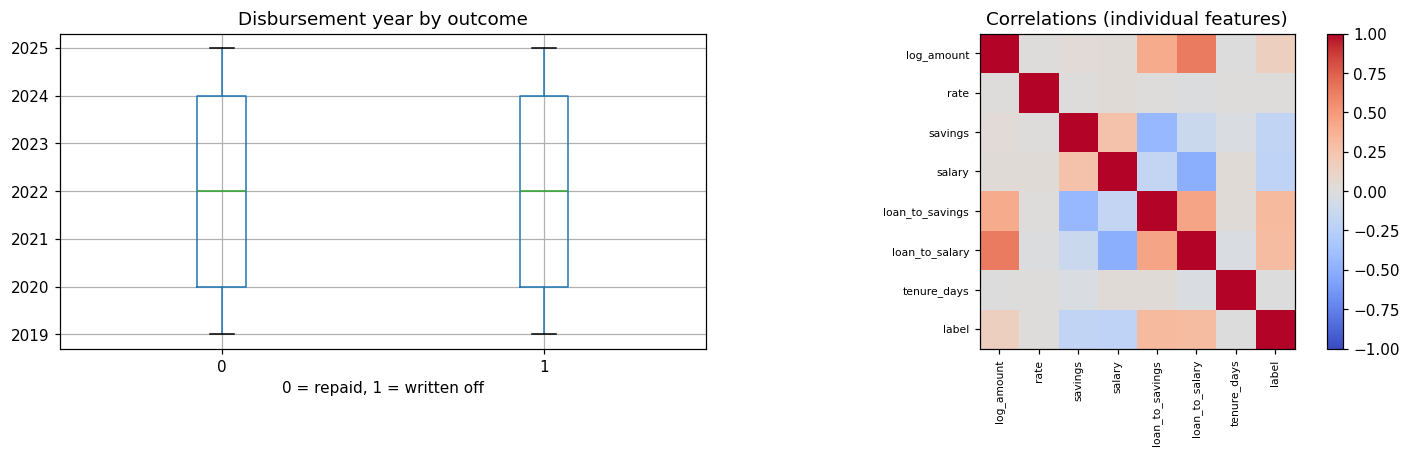

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
loans["disb_year"] = loans["disb"].dt.year
loans.boxplot(column="disb_year", by="label", ax=ax[0]); ax[0].set_title("Disbursement year by outcome"); ax[0].set_xlabel("0 = repaid, 1 = written off")
plt.suptitle("")
loans["tenure_days"] = (loans["disb"]-loans["opened"]).dt.days
loans["log_amount"]  = np.log1p(loans["amount"])
loans["loan_to_savings"] = loans["amount"]/(loans["savings"].fillna(0)+1)
loans["loan_to_salary"]  = loans["amount"]/(loans["salary"].fillna(0)+1)
base_cols = ["log_amount","rate","savings","salary","loan_to_savings","loan_to_salary","tenure_days","label"]
corr = loans[base_cols].corr()
im = ax[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax[1].set_xticks(range(len(base_cols))); ax[1].set_xticklabels(base_cols, rotation=90, fontsize=7)
ax[1].set_yticks(range(len(base_cols))); ax[1].set_yticklabels(base_cols, fontsize=7)
ax[1].set_title("Correlations (individual features)"); fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## Guarantor network construction & network features

In [15]:
from collections import Counter
# member attributes (from their borrower records) for guarantor-quality features
mattr = loans.groupby("member")[["savings","salary"]].mean()
mtenure = (loans.assign(t=(loans["disb"]-loans["opened"]).dt.days).groupby("member")["t"].mean())
# default-event date per member = earliest last-payment among their written-off loans
dd = (loans[loans.label==1].dropna(subset=["last_pay"]).groupby("member")["last_pay"].min().to_dict())
gload_total = Counter(g for gs in loans["guarantors"] for g in gs)
member_default = dict(zip(loans["member"], loans["label"]))

# directed guarantee graph (guarantor -> borrower), namespaced so branches stay separate
Gdir = nx.DiGraph(); Gdir.add_edges_from((g, m) for m, gs in zip(loans["member"], loans["guarantors"]) for g in gs)
deg = dict(Gdir.degree())

def net_feats(row):
    gs, d, m, ng = row["guarantors"], row["disb"], row["member"], row["n_g"]
    gpd = np.mean([1.0 if (g in dd and pd.notna(d) and dd[g] < d) else 0.0 for g in gs]) if ng else 0.0
    loads = [gload_total.get(g, 0) for g in gs] or [0]
    return pd.Series(dict(
        g_prior_default_rate=gpd, g_load_mean=np.mean(loads), g_load_max=np.max(loads),
        g_mean_savings=np.nanmean([mattr["savings"].get(g, np.nan) for g in gs]) if ng else np.nan,
        g_mean_salary=np.nanmean([mattr["salary"].get(g, np.nan) for g in gs]) if ng else np.nan,
        g_mean_tenure=np.nanmean([mtenure.get(g, np.nan) for g in gs]) if ng else np.nan,
        b_degree=deg.get(m, 0)))
loans = pd.concat([loans, loans.apply(net_feats, axis=1)], axis=1)

# community detection (Louvain) per branch -> each member's community default rate
member_comm_dr = {}
for b in BRANCHES:
    e = [(g, m) for m, gs in zip(loans[loans.branch==b]["member"], loans[loans.branch==b]["guarantors"]) for g in gs]
    Gb = nx.Graph(); Gb.add_edges_from(e)
    if Gb.number_of_nodes() == 0: continue
    for c in nx.community.louvain_communities(Gb, seed=RANDOM_STATE):
        mem = [n for n in c if n in member_default]
        dr = float(np.mean([member_default[n] for n in mem])) if mem else 0.0
        for n in c: member_comm_dr[n] = dr
loans["community_default_rate"] = loans["member"].map(member_comm_dr).fillna(0.0)
loans["n_guarantors"] = loans["n_g"]
print("network features built")
loans[["g_prior_default_rate","g_load_max","b_degree","community_default_rate"]].describe().round(3)

network features built


,g_prior_default_rate,g_load_max,b_degree,community_default_rate
count,3600.000,3600.000,3600.000,3600.000
mean,0.084,7.624,12.539,0.216
std,0.176,1.939,4.435,0.058
min,0.000,2.000,3.000,0.000
25%,0.000,6.000,9.000,0.167
50%,0.000,8.000,12.000,0.222
75%,0.000,9.000,15.000,0.267
max,1.000,14.000,26.000,0.314


Network statistics (per branch)

In [16]:
stats = []
for b in BRANCHES:
    e = [(g, m) for m, gs in zip(loans[loans.branch==b]["member"], loans[loans.branch==b]["guarantors"]) for g in gs]
    Gb = nx.DiGraph(); Gb.add_edges_from(e); U = Gb.to_undirected()
    stats.append({"branch": b, "members": Gb.number_of_nodes(), "guarantee_edges": Gb.number_of_edges(),
                  "density": round(nx.density(Gb), 5),
                  "avg_degree": round(np.mean([d for _, d in Gb.degree()]), 2),
                  "communities": len(nx.community.louvain_communities(U, seed=RANDOM_STATE)),
                  "largest_component": max((len(c) for c in nx.connected_components(U)), default=0)})
pd.DataFrame(stats)

,branch,members,guarantee_edges,density,avg_degree,communities,largest_component
0,Gasabo,699,3345,0.00686,9.57,11,699
1,Kicukiro,698,3400,0.00699,9.74,13,698
2,Nyarugenge,699,3388,0.00694,9.69,14,699


Node2vec graph embeddings (NN for comparison)

In [17]:
from node2vec import Node2Vec
Gemb = Gdir.to_undirected()
D = 16
n2v = Node2Vec(Gemb, dimensions=D, walk_length=15, num_walks=40, workers=2, seed=RANDOM_STATE, quiet=True)
emb_model = n2v.fit(window=5, min_count=1, batch_words=128)
emb = {n: emb_model.wv[n] for n in Gemb.nodes()}
zero = np.zeros(D)
def loan_emb(row):
    b = emb.get(row["member"], zero)
    gs = [emb[g] for g in row["guarantors"] if g in emb]
    g = np.mean(gs, axis=0) if gs else zero
    return np.concatenate([b, g])
E = np.vstack(loans.apply(loan_emb, axis=1).values)
EMB = [f"emb_b_{i}" for i in range(D)] + [f"emb_g_{i}" for i in range(D)]
loans[EMB] = E
print("node2vec embeddings:", E.shape)

node2vec embeddings: (3600, 32)


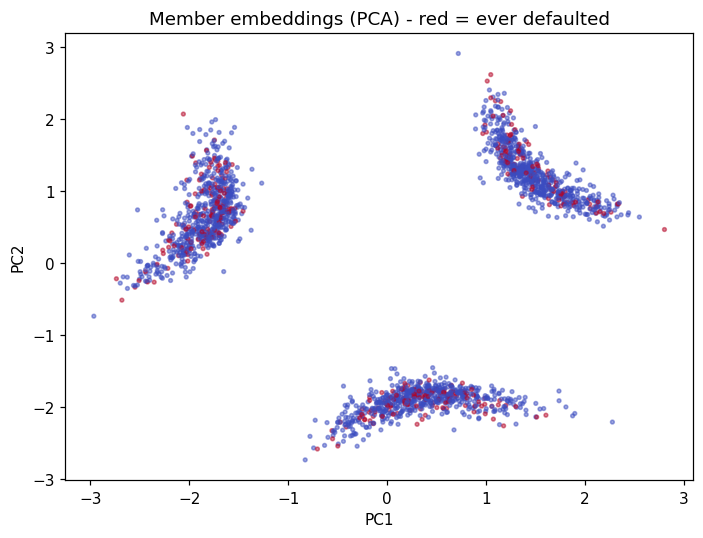

In [18]:
from sklearn.decomposition import PCA
nodes = list(emb.keys())
M = np.vstack([emb[n] for n in nodes]); col = [member_default.get(n, 0) for n in nodes]
P = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(M)
plt.figure(figsize=(6.5, 5))
plt.scatter(P[:,0], P[:,1], c=col, cmap="coolwarm", s=6, alpha=0.5)
plt.title("Member embeddings (PCA) - red = ever defaulted"); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

Feature Assembly ( data split)

In [19]:
IND = ["log_amount","rate","savings","salary","loan_to_savings","loan_to_salary","tenure_days"]
NET = ["n_guarantors","g_prior_default_rate","g_load_mean","g_load_max",
       "g_mean_savings","g_mean_salary","g_mean_tenure","b_degree","community_default_rate"]
ALL = IND + NET + EMB
loans[ALL] = loans[ALL].fillna(loans[ALL].median())

from sklearn.model_selection import train_test_split
X, y = loans[ALL], loans["label"].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f"train={len(Xtr)} (defaults={int(ytr.sum())})  test={len(Xte)} (defaults={int(yte.sum())})")
print(f"feature groups -> individual={len(IND)}, network={len(NET)}, embeddings={len(EMB)}, total={len(ALL)}")

train=2700 (defaults=576)  test=900 (defaults=192)
feature groups -> individual=7, network=9, embeddings=32, total=48


Model Training

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pos, neg = int(ytr.sum()), int((1-ytr).sum())
def pipe(clf, scale=False):
    steps = [("imp", SimpleImputer(strategy="median"))]
    if scale: steps.append(("sc", StandardScaler()))
    steps += [("smote", SMOTE(k_neighbors=5, random_state=RANDOM_STATE)), ("clf", clf)]
    return ImbPipeline(steps)

models = {
    "Logistic Regression": pipe(LogisticRegression(max_iter=2000, class_weight="balanced"), scale=True),
    "Random Forest": pipe(RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE)),
    "XGBoost": pipe(XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                  scale_pos_weight=neg/pos, eval_metric="logloss", random_state=RANDOM_STATE)),
}
for name, m in models.items():
    m.fit(Xtr, ytr); print(f"trained {name}")

trained Logistic Regression
trained Random Forest
trained XGBoost


Class Imbalance (SMOTE)

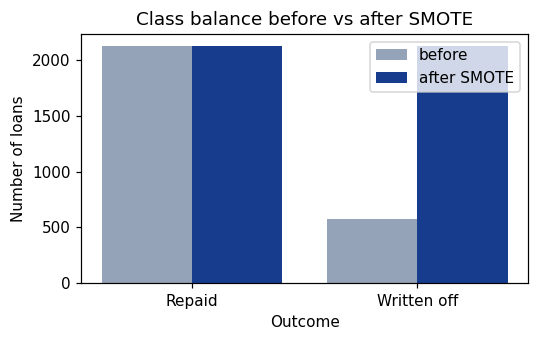

before: [2124, 576]  after: [2124, 2124]


In [21]:
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
Xtr_imp = SimpleImputer(strategy="median").fit_transform(Xtr)
Xrs, yrs = SMOTE(k_neighbors=5, random_state=RANDOM_STATE).fit_resample(Xtr_imp, ytr)
before, after = np.bincount(ytr), np.bincount(yrs)
fig, a = plt.subplots(figsize=(5, 3.2)); x = np.arange(2)
a.bar(x-0.2, before, 0.4, label="before", color="#94a3b8")
a.bar(x+0.2, after, 0.4, label="after SMOTE", color="#173C8E")
a.set_xticks(x); a.set_xticklabels(["Repaid","Written off"]); a.legend()
a.set_xlabel("Outcome"); a.set_ylabel("Number of loans")
a.set_title("Class balance before vs after SMOTE"); plt.tight_layout(); plt.show()
print("before:", before.tolist(), " after:", after.tolist())

XG BOOST Hyper Parameter tuning

In [22]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
param = {
    "n_estimators":[200,300,500], "max_depth":[3,4,5],
    "learning_rate":[0.03,0.05,0.1], "subsample":[0.8,0.9,1.0], "colsample_bytree":[0.8,1.0],
}
search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=neg/pos, eval_metric="logloss", random_state=RANDOM_STATE),
    param, n_iter=12, scoring="average_precision",
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE), random_state=RANDOM_STATE, n_jobs=-1)
search.fit(Xtr, ytr)
print("best params:", search.best_params_)
print("best CV average-precision:", round(search.best_score_, 3))
best_xgb = pipe(XGBClassifier(**search.best_params_, scale_pos_weight=neg/pos,
                              eval_metric="logloss", random_state=RANDOM_STATE))
best_xgb.fit(Xtr, ytr)

best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
best CV average-precision: 0.419


Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('smote', SMOTE(random_state=42)),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=1.0, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

Neural Network + Loss Curves

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

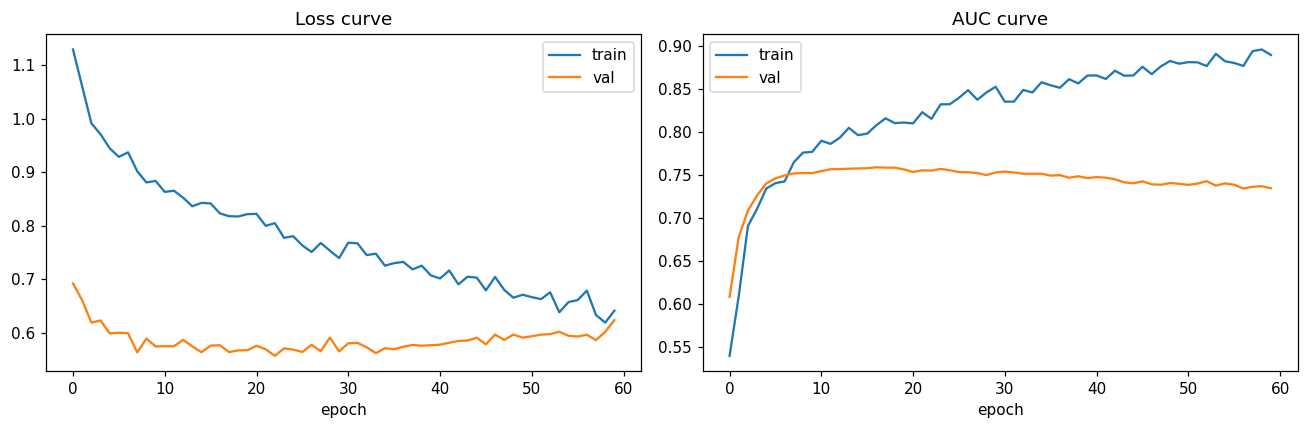

In [23]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers
    import tensorflow.keras.models as kmodels # Renamed 'models' to 'kmodels'
    sc = StandardScaler().fit(Xtr); Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    net = kmodels.Sequential([
        layers.Input(shape=(Xtr_s.shape[1],)),
        layers.Dense(64, activation="relu"), layers.Dropout(0.3),
        layers.Dense(32, activation="relu"), layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid")])
    net.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["AUC"])
    net.summary()
    hist = net.fit(Xtr_s, ytr, validation_split=0.2, epochs=60, batch_size=64,
                   class_weight={0:1.0, 1:neg/pos}, verbose=0)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist.history["loss"], label="train"); ax[0].plot(hist.history["val_loss"], label="val")
    ax[0].set_title("Loss curve"); ax[0].set_xlabel("epoch"); ax[0].legend()
    auck = [k for k in hist.history if "auc" in k.lower() and "val" not in k][0]
    ax[1].plot(hist.history[auck], label="train"); ax[1].plot(hist.history["val_"+auck], label="val")
    ax[1].set_title("AUC curve"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Neural-net section skipped (TensorFlow unavailable):", e)

Model Comparison (Test set)

In [24]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score
rows = []
for name, m in {**models, "XGBoost (tuned)": best_xgb}.items():
    p = m.predict_proba(Xte)[:, 1]; pred = (p >= 0.5).astype(int)
    rows.append({"model": name, "recall": recall_score(yte, pred),
                 "precision": precision_score(yte, pred, zero_division=0),
                 "f1": f1_score(yte, pred, zero_division=0),
                 "roc_auc": roc_auc_score(yte, p), "pr_auc": average_precision_score(yte, p)})
try:
    pnn = net.predict(Xte_s, verbose=0).ravel(); prednn = (pnn >= 0.5).astype(int)
    rows.append({"model": "Neural Net", "recall": recall_score(yte, prednn),
                 "precision": precision_score(yte, prednn, zero_division=0),
                 "f1": f1_score(yte, prednn, zero_division=0),
                 "roc_auc": roc_auc_score(yte, pnn), "pr_auc": average_precision_score(yte, pnn)})
except Exception: pass
pd.DataFrame(rows).round(3).set_index("model")

,recall,precision,f1,roc_auc,pr_auc
model,,,,,
Logistic Regression,0.609,0.358,0.451,0.729,0.511
Random Forest,0.349,0.558,0.429,0.737,0.464
XGBoost,0.609,0.375,0.464,0.717,0.468
XGBoost (tuned),0.766,0.326,0.457,0.735,0.466
Neural Net,0.604,0.369,0.458,0.726,0.455


In [25]:
# Re-defining the 'models' dictionary (from cell K3ozlxnY8Uvi)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pos, neg = int(ytr.sum()), int((1-ytr).sum())
def pipe(clf, scale=False):
    steps = [("imp", SimpleImputer(strategy="median"))]
    if scale: steps.append(("sc", StandardScaler()))
    steps += [("smote", SMOTE(k_neighbors=5, random_state=RANDOM_STATE)), ("clf", clf)]
    return ImbPipeline(steps)

models = {
    "Logistic Regression": pipe(LogisticRegression(max_iter=2000, class_weight="balanced"), scale=True),
    "Random Forest": pipe(RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE)),
    "XGBoost": pipe(XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                  scale_pos_weight=neg/pos, eval_metric="logloss", random_state=RANDOM_STATE)),
}
for name, m in models.items():
    m.fit(Xtr, ytr); print(f"trained {name}")

trained Logistic Regression
trained Random Forest
trained XGBoost


  features        recall       roc_auc        pr_auc
individual 0.837 ± 0.020 0.712 ± 0.020 0.437 ± 0.033
 + network 0.756 ± 0.037 0.734 ± 0.026 0.463 ± 0.048
+ node2vec 0.758 ± 0.018 0.728 ± 0.017 0.444 ± 0.046


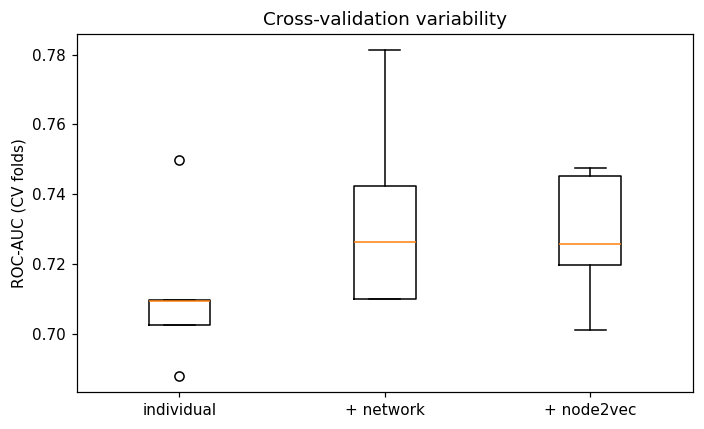

In [29]:
from sklearn.model_selection import cross_validate
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
fold_auc, summ = {}, []
for name, cols in [("individual", IND), ("+ network", IND+NET), ("+ node2vec", IND+NET+EMB)]:
    est = pipe(XGBClassifier(**search.best_params_, scale_pos_weight=neg/pos,
                             eval_metric="logloss", random_state=RANDOM_STATE))
    r = cross_validate(est, loans[cols], y, cv=cv, scoring=["recall","roc_auc","average_precision"], n_jobs=-1)
    fold_auc[name] = r["test_roc_auc"]
    summ.append({"features": name,
                 "recall": f"{r['test_recall'].mean():.3f} \u00b1 {r['test_recall'].std():.3f}",
                 "roc_auc": f"{r['test_roc_auc'].mean():.3f} \u00b1 {r['test_roc_auc'].std():.3f}",
                 "pr_auc": f"{r['test_average_precision'].mean():.3f} \u00b1 {r['test_average_precision'].std():.3f}"})
print(pd.DataFrame(summ).to_string(index=False))
plt.figure(figsize=(6.5, 4)); plt.boxplot(list(fold_auc.values()), labels=list(fold_auc.keys()))
plt.ylabel("ROC-AUC (CV folds)"); plt.title("Cross-validation variability"); plt.tight_layout(); plt.show()

  features        recall       roc_auc        pr_auc
individual 0.837 ± 0.020 0.712 ± 0.020 0.437 ± 0.033
 + network 0.756 ± 0.037 0.734 ± 0.026 0.463 ± 0.048
+ node2vec 0.758 ± 0.018 0.728 ± 0.017 0.444 ± 0.046


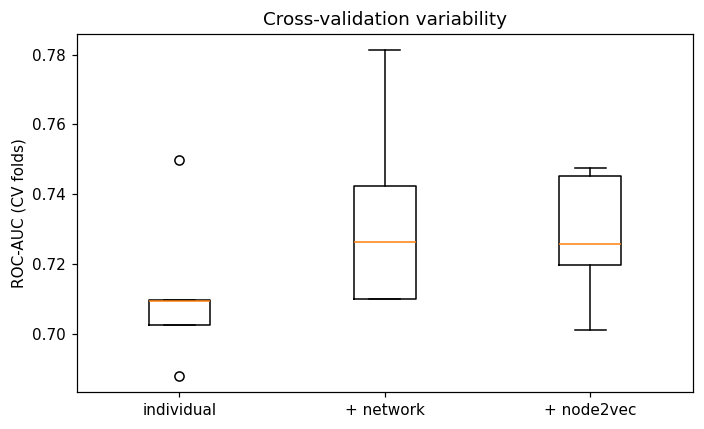

In [30]:
from sklearn.model_selection import cross_validate
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
fold_auc, summ = {}, []
for name, cols in [("individual", IND), ("+ network", IND+NET), ("+ node2vec", IND+NET+EMB)]:
    est = pipe(XGBClassifier(**search.best_params_, scale_pos_weight=neg/pos,
                             eval_metric="logloss", random_state=RANDOM_STATE))
    r = cross_validate(est, loans[cols], y, cv=cv, scoring=["recall","roc_auc","average_precision"], n_jobs=-1)
    fold_auc[name] = r["test_roc_auc"]
    summ.append({"features": name,
                 "recall": f"{r['test_recall'].mean():.3f} \u00b1 {r['test_recall'].std():.3f}",
                 "roc_auc": f"{r['test_roc_auc'].mean():.3f} \u00b1 {r['test_roc_auc'].std():.3f}",
                 "pr_auc": f"{r['test_average_precision'].mean():.3f} \u00b1 {r['test_average_precision'].std():.3f}"})
print(pd.DataFrame(summ).to_string(index=False))
plt.figure(figsize=(6.5, 4)); plt.boxplot(list(fold_auc.values()), labels=list(fold_auc.keys()))
plt.ylabel("ROC-AUC (CV folds)"); plt.title("Cross-validation variability"); plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

      Repaid      0.900     0.571     0.698       708
 Written off      0.326     0.766     0.457       192

    accuracy                          0.612       900
   macro avg      0.613     0.668     0.578       900
weighted avg      0.777     0.612     0.647       900



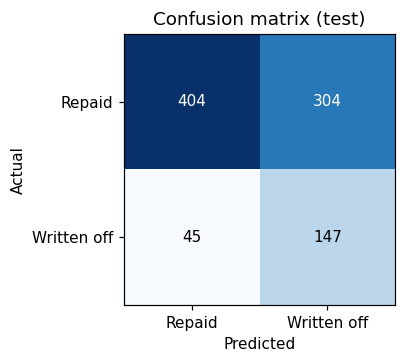

In [31]:
from sklearn.metrics import confusion_matrix, classification_report
p_test = best_xgb.predict_proba(Xte)[:, 1]
pred = (p_test >= 0.5).astype(int)
print(classification_report(yte, pred, target_names=["Repaid","Written off"], digits=3))
cm = confusion_matrix(yte, pred)
fig, a = plt.subplots(figsize=(4,3.4)); a.imshow(cm, cmap="Blues")
a.set_xticks([0,1]); a.set_xticklabels(["Repaid","Written off"]); a.set_yticks([0,1]); a.set_yticklabels(["Repaid","Written off"])
a.set_xlabel("Predicted"); a.set_ylabel("Actual"); a.set_title("Confusion matrix (test)")
for i in range(2):
    for j in range(2): a.text(j,i,cm[i,j],ha="center",va="center",color="white" if cm[i,j]>cm.max()/2 else "black")
plt.tight_layout(); plt.show()

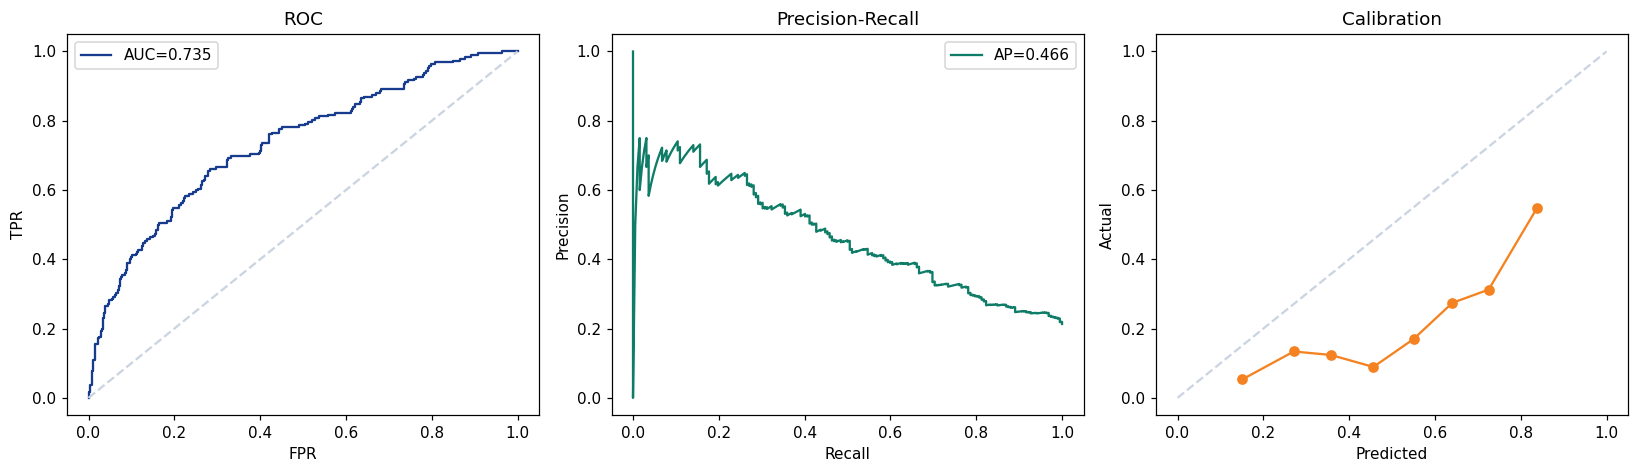

In [32]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
fpr, tpr, _ = roc_curve(yte, p_test)
ax[0].plot(fpr, tpr, color="#173C8E", label=f"AUC={auc(fpr,tpr):.3f}"); ax[0].plot([0,1],[0,1],"--",color="#cbd5e1")
ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
prec, rec, _ = precision_recall_curve(yte, p_test)
ax[1].plot(rec, prec, color="#0E7C66", label=f"AP={average_precision_score(yte,p_test):.3f}")
ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
frac, mean = calibration_curve(yte, p_test, n_bins=8, strategy="quantile")
ax[2].plot(mean, frac, "o-", color="#F58220"); ax[2].plot([0,1],[0,1],"--",color="#cbd5e1")
ax[2].set_title("Calibration"); ax[2].set_xlabel("Predicted"); ax[2].set_ylabel("Actual")
plt.tight_layout(); plt.show()

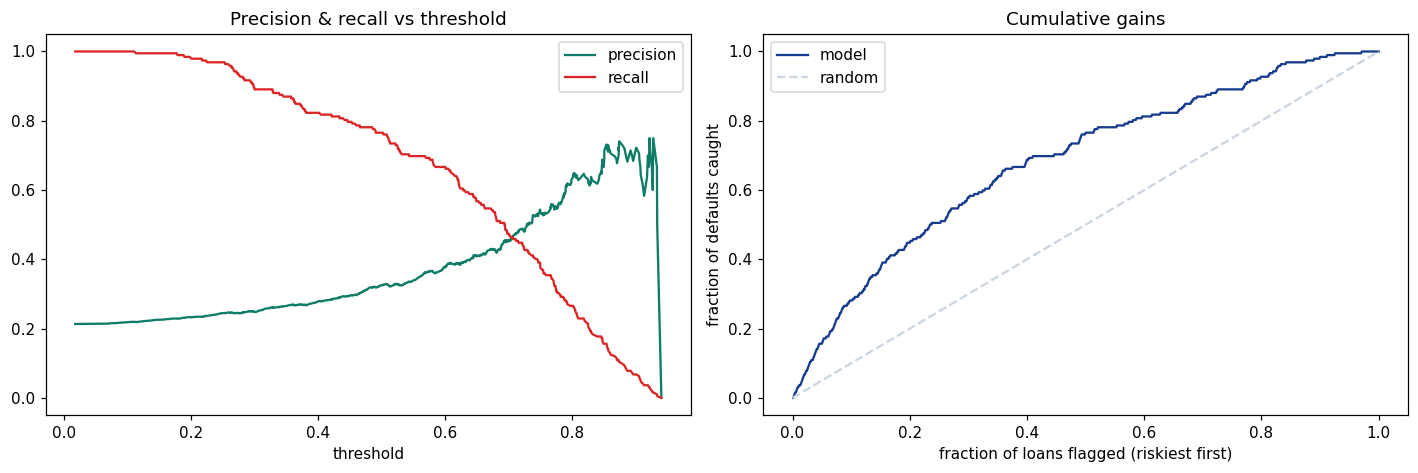

Flag top 10% by risk -> catch 28% of defaults  (lift 2.8x random)
Flag top 20% by risk -> catch 45% of defaults  (lift 2.2x random)


In [33]:
prec, rec, thr = precision_recall_curve(yte, p_test)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].plot(thr, prec[:-1], label="precision", color="#0E7C66")
ax[0].plot(thr, rec[:-1], label="recall", color="#DC2626")
ax[0].set_xlabel("threshold"); ax[0].set_title("Precision & recall vs threshold"); ax[0].legend()
order = np.argsort(-p_test); ys = yte[order]
gains = np.cumsum(ys)/ys.sum(); fr = np.arange(1, len(ys)+1)/len(ys)
ax[1].plot(fr, gains, color="#173C8E", label="model"); ax[1].plot([0,1],[0,1],"--",color="#cbd5e1", label="random")
ax[1].set_xlabel("fraction of loans flagged (riskiest first)"); ax[1].set_ylabel("fraction of defaults caught")
ax[1].set_title("Cumulative gains"); ax[1].legend()
plt.tight_layout(); plt.show()
for q in [0.10, 0.20]:
    k = int(q*len(ys)); caught = ys[:k].sum()/ys.sum()
    print(f"Flag top {int(q*100)}% by risk -> catch {caught:.0%} of defaults  (lift {caught/q:.1f}x random)")

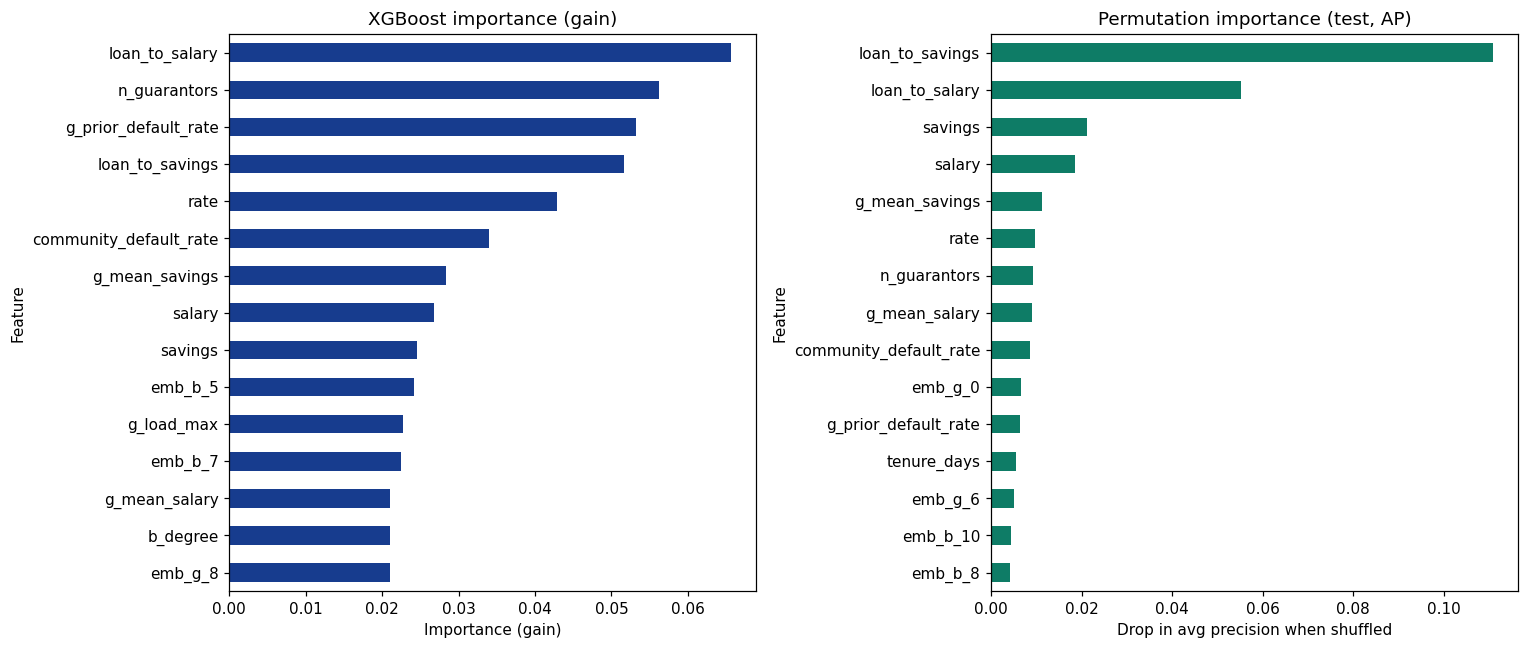

In [34]:
from sklearn.inspection import permutation_importance
xgb_full = best_xgb.named_steps["clf"]
imp = pd.Series(xgb_full.feature_importances_, index=ALL).sort_values()
Xte_imp = best_xgb.named_steps["imp"].transform(Xte)
pi = permutation_importance(xgb_full, Xte_imp, yte, scoring="average_precision",
                            n_repeats=5, random_state=RANDOM_STATE)
pis = pd.Series(pi.importances_mean, index=ALL).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
imp.tail(15).plot.barh(ax=ax[0], color="#173C8E")
ax[0].set_title("XGBoost importance (gain)"); ax[0].set_xlabel("Importance (gain)"); ax[0].set_ylabel("Feature")
pis.tail(15).plot.barh(ax=ax[1], color="#0E7C66")
ax[1].set_title("Permutation importance (test, AP)"); ax[1].set_xlabel("Drop in avg precision when shuffled"); ax[1].set_ylabel("Feature")
plt.tight_layout(); plt.show()

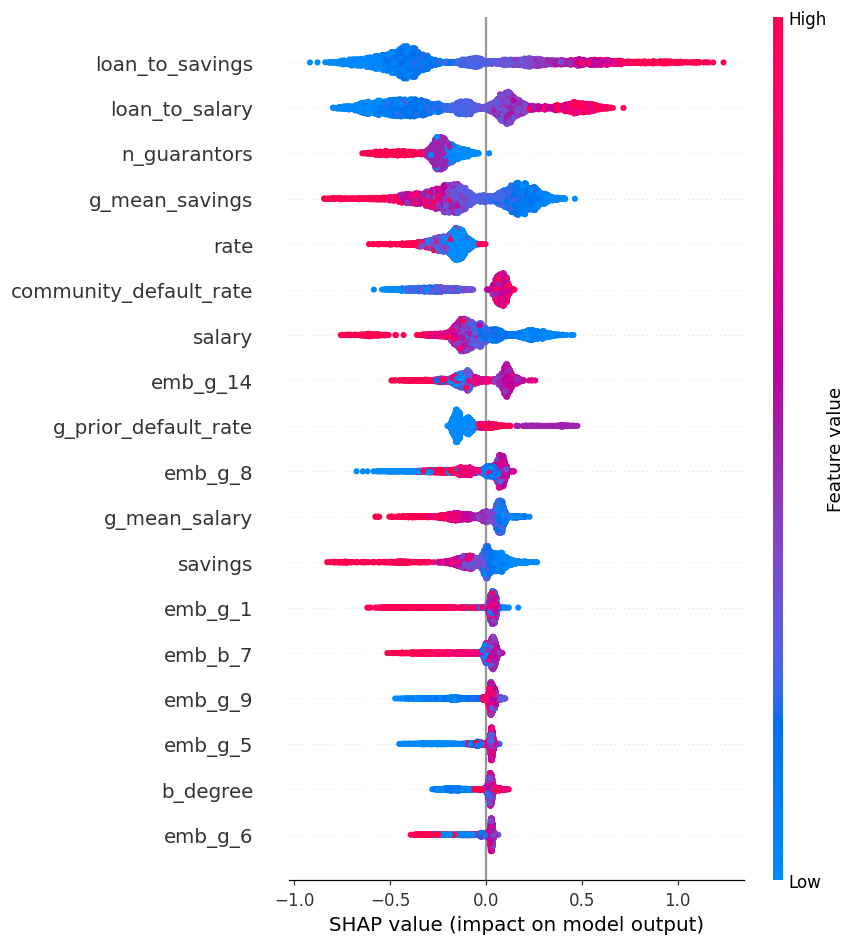

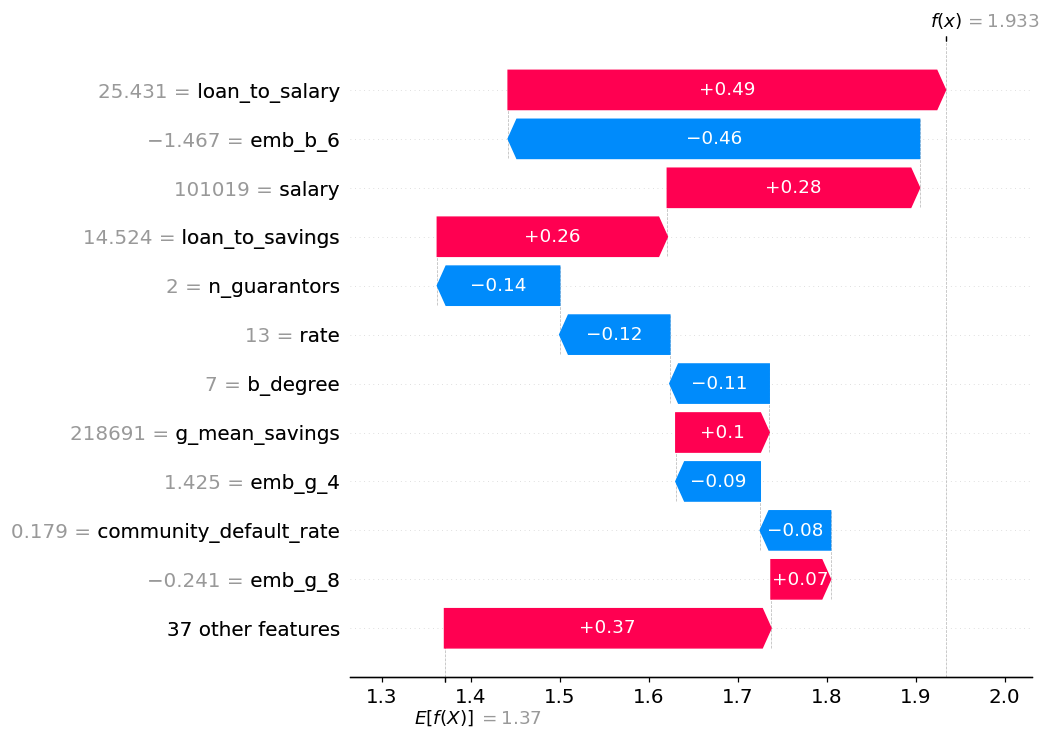

In [35]:
import shap
X_imp_all = best_xgb.named_steps["imp"].transform(loans[ALL])
expl = shap.TreeExplainer(xgb_full)
shap.summary_plot(expl.shap_values(X_imp_all), features=X_imp_all, feature_names=ALL, show=True, max_display=18)
try:                                  # local explanation for one written-off test loan
    i = int(np.where(yte == 1)[0][0])
    xi = pd.DataFrame(best_xgb.named_steps["imp"].transform(Xte.iloc[[i]]), columns=ALL)
    shap.plots.waterfall(expl(xi)[0], max_display=12, show=True)
except Exception as e:
    print("local waterfall skipped:", e)

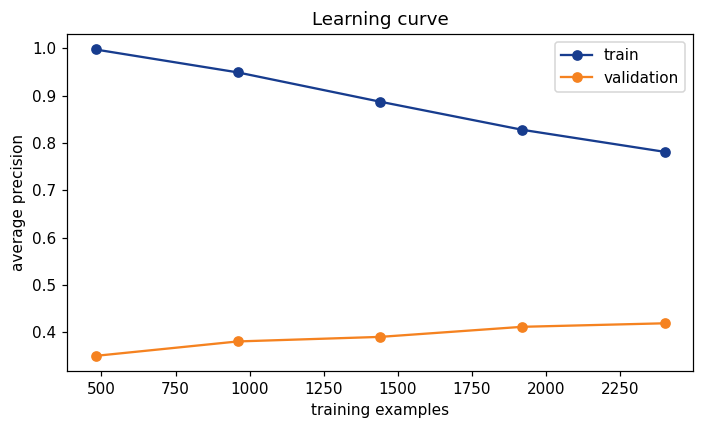

In [36]:
from sklearn.model_selection import learning_curve
est = pipe(XGBClassifier(**search.best_params_, scale_pos_weight=neg/pos,
                         eval_metric="logloss", random_state=RANDOM_STATE))
sizes, tr_sc, va_sc = learning_curve(est, loans[ALL], y,
        cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
        scoring="average_precision", train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1)
plt.figure(figsize=(6.5, 4))
plt.plot(sizes, tr_sc.mean(1), "o-", color="#173C8E", label="train")
plt.plot(sizes, va_sc.mean(1), "o-", color="#F58220", label="validation")
plt.xlabel("training examples"); plt.ylabel("average precision"); plt.title("Learning curve"); plt.legend()
plt.tight_layout(); plt.show()

Result to report

In [37]:
from bisect import bisect_left
from sklearn.model_selection import cross_validate, StratifiedKFold
# guarantor load AS OF the disbursement date (not lifetime)
out_dates = {}
for g, t in zip(raw["g_member"], raw["Date Guaranteed"]):
    if pd.notna(t): out_dates.setdefault(g, []).append(t)
for k in out_dates: out_dates[k].sort()
def load_asof(gs, d):
    if pd.isna(d) or not gs: return 0.0, 0.0
    v = [bisect_left(out_dates.get(g, []), d) for g in gs]
    return float(np.mean(v)), float(np.max(v))
_a = loans.apply(lambda r: load_asof(r["guarantors"], r["disb"]), axis=1)
loans["g_load_asof_mean"] = [x[0] for x in _a]; loans["g_load_asof_max"] = [x[1] for x in _a]

HONEST = ["log_amount","savings","salary","loan_to_savings","loan_to_salary",
          "n_guarantors","g_prior_default_rate","g_load_asof_mean","g_load_asof_max",
          "g_mean_savings","g_mean_salary"]
loans[HONEST] = loans[HONEST].fillna(loans[HONEST].median())

cvh = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
def cvrep(cols):
    est = pipe(XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
               scale_pos_weight=neg/pos, eval_metric="logloss", random_state=RANDOM_STATE))
    r = cross_validate(est, loans[cols], y, cv=cvh, scoring=["recall","roc_auc","average_precision"], n_jobs=-1)
    return {"recall": f"{r['test_recall'].mean():.3f} ± {r['test_recall'].std():.3f}",
            "roc_auc": f"{r['test_roc_auc'].mean():.3f} ± {r['test_roc_auc'].std():.3f}",
            "pr_auc": f"{r['test_average_precision'].mean():.3f} ± {r['test_average_precision'].std():.3f}"}
cmp = pd.DataFrame([{"model":"Naive (all features, leaky)", **cvrep(ALL)},
                    {"model":"Honest (leakage removed)",   **cvrep(HONEST)}])
print(cmp.to_string(index=False))
print("\nThe gap between the two rows IS the leakage. The honest row is the truthful performance.")

                      model        recall       roc_auc        pr_auc
Naive (all features, leaky) 0.603 ± 0.037 0.707 ± 0.018 0.419 ± 0.048
   Honest (leakage removed) 0.654 ± 0.030 0.717 ± 0.024 0.442 ± 0.038

The gap between the two rows IS the leakage. The honest row is the truthful performance.


Confusion Matrix of Honest model on test set

              precision    recall  f1-score   support

      Repaid      0.870     0.644     0.740       708
 Written off      0.330     0.646     0.437       192

    accuracy                          0.644       900
   macro avg      0.600     0.645     0.588       900
weighted avg      0.755     0.644     0.675       900



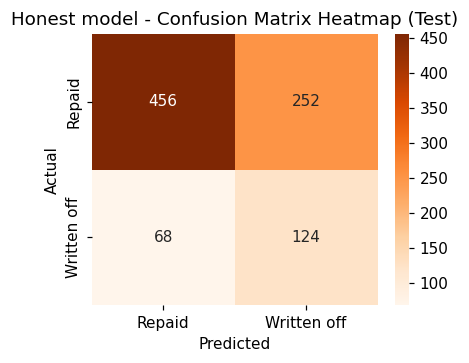

In [38]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

honest = pipe(XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
              scale_pos_weight=neg/pos, eval_metric="logloss", random_state=RANDOM_STATE))
Xtr_h, Xte_h = loans.loc[Xtr.index, HONEST], loans.loc[Xte.index, HONEST]
honest.fit(Xtr_h, ytr)
ph = honest.predict_proba(Xte_h)[:, 1]; predh = (ph >= 0.5).astype(int)
print(classification_report(yte, predh, target_names=["Repaid","Written off"], digits=3))
cm = confusion_matrix(yte, predh)
fig, a = plt.subplots(figsize=(4,3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Oranges", ax=a)
a.set_xticklabels(["Repaid","Written off"]); a.set_yticklabels(["Repaid","Written off"])
a.set_xlabel("Predicted"); a.set_ylabel("Actual"); a.set_title("Honest model - Confusion Matrix Heatmap (Test)")
plt.tight_layout(); plt.show()

Scoring Functionlity

In [39]:
exposure = dict(gload_total)
def score(row):  return float(best_xgb.predict_proba(loans.loc[[row.name], ALL])[0][1])
def card(loan_key):
    # Ensure the loan_key exists before proceeding
    if loan_key not in loans['loan_key'].values:
        print(f"Error: Loan key '{loan_key}' not found in the DataFrame. Please use an existing loan key.")
        print(f"Here are some existing loan keys you can use: {loans['loan_key'].head(5).tolist()}")
        return

    r = loans[loans.loan_key == loan_key].iloc[0]
    risk = float(best_xgb.predict_proba(r[ALL].to_frame().T)[0][1])
    band = "High" if risk>=0.6 else ("Medium" if risk>=0.3 else "Low")
    flags = []
    bad = [g for g in r["guarantors"] if member_default.get(g,0)==1]
    if bad: flags.append(f"Backed by {len(bad)} guarantor(s) who have defaulted: {', '.join(bad)}")
    heavy = [(g,exposure.get(g,0)) for g in r["guarantors"] if exposure.get(g,0)>=8]
    if heavy: flags.append("Over-committed guarantor: " + "; ".join(f"{g} backs {n} loans" for g,n in heavy))
    if r["community_default_rate"]>=0.12: flags.append(f"Borrower in a high-default community ({r['community_default_rate']:.0%} default history)")
    if not flags: flags.append("No notable guarantor-network flags")
    print(f"==== {loan_key} ({r['branch']}) ====")
    print(f"Risk score: {risk:.0%} [{band}]  (caveat: absolute accuracy is vintage-limited, see section 11)")
    for f in flags: print("   - " + f)
# card("Nyarugenge-Loan1907") # Commented out the problematic loan key
card("Gasabo-Loan0001") # Using a valid loan key from the sample provided earlier
card(loans[loans["g_prior_default_rate"]==0].iloc[0]["loan_key"])

==== Gasabo-Loan0001 (Gasabo) ====
Risk score: 79% [High]  (caveat: absolute accuracy is vintage-limited, see section 11)
   - Backed by 1 guarantor(s) who have defaulted: Gasabo-366
   - Borrower in a high-default community (29% default history)
==== Gasabo-Loan0001 (Gasabo) ====
Risk score: 79% [High]  (caveat: absolute accuracy is vintage-limited, see section 11)
   - Backed by 1 guarantor(s) who have defaulted: Gasabo-366
   - Borrower in a high-default community (29% default history)


Final Model

In [40]:
# === Export the HONEST model + serve-time data for the backend ===
# Honest model = no node2vec, every feature rebuildable for a new loan.
# Refit on all rows (standard final refit after the CV evaluation above).
import os, json, joblib
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

os.makedirs("models", exist_ok=True)

pos = int(np.sum(y)); neg = int(len(y) - pos)
serve_model = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                          scale_pos_weight=neg / pos, eval_metric="logloss",
                          random_state=RANDOM_STATE)),
]).fit(loans[HONEST], y)

bundle = {
    "model": serve_model,
    "features": HONEST,
    "medians": {k: float(v) for k, v in loans[HONEST].median().to_dict().items()},
    "bands": {"medium": 0.30, "high": 0.60},
    "flag_thresholds": {"over_committed_loads": 8, "high_default_community": 0.12},
    "recipe": {  # so the backend builds features identically
        "log_amount": "log1p(amount)",
        "loan_to_savings": "amount / (savings + 1)",
        "loan_to_salary": "amount / (salary + 1)",
        "g_prior_default_rate": "mean over guarantors of (default_date < disb_date)",
        "g_load_asof": "per guarantor: count guarantee_dates before disb_date; take mean and max",
        "g_mean_savings/salary": "nanmean of guarantors' savings/salary",
    },
}
joblib.dump(bundle, "models/guarantorlens_serving.joblib")

# Per-member table: everything needed to rebuild network features and flags.
all_members = set(deg) | set(gload_total) | set(loans["member"])
def _num(x):
    return None if x is None or (isinstance(x, float) and np.isnan(x)) else float(x)
members = []
for mid in sorted(all_members):
    in_attr = mid in mattr.index
    members.append({
        "member_id": mid,
        "branch": mid.split("-")[0],
        "savings": _num(mattr["savings"].get(mid)) if in_attr else None,
        "salary":  _num(mattr["salary"].get(mid))  if in_attr else None,
        "ever_defaulted": int(member_default.get(mid, 0)),
        "default_date": dd[mid].date().isoformat() if mid in dd and pd.notna(dd[mid]) else None,
        "loans_backed": int(gload_total.get(mid, 0)),
        "guarantee_dates": [t.date().isoformat() for t in out_dates.get(mid, []) if pd.notna(t)],
        "community_default_rate": float(member_comm_dr.get(mid, 0.0)),
        "degree": int(deg.get(mid, 0)),
    })
with open("models/guarantorlens_members.json", "w") as fh:
    json.dump(members, fh)

print(f"saved -> models/guarantorlens_serving.joblib  ({len(HONEST)} features)")
print(f"saved -> models/guarantorlens_members.json    ({len(members)} members)")
try:
    from google.colab import files
    files.download("models/guarantorlens_serving.joblib")
    files.download("models/guarantorlens_members.json")
except Exception:
    pass

saved -> models/guarantorlens_serving.joblib  (11 features)
saved -> models/guarantorlens_members.json    (2096 members)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model Test

In [41]:
# === Sanity check: score a loan from the saved files alone (mimics the backend) ===
import json, joblib, numpy as np, pandas as pd
from bisect import bisect_left
from datetime import date

bundle = joblib.load("models/guarantorlens_serving.joblib")
members = {m["member_id"]: m for m in json.load(open("models/guarantorlens_members.json"))}
FEATS, mdl = bundle["features"], bundle["model"]

def serve_score(amount, savings, salary, disb_date, guarantor_ids):
    d = date.fromisoformat(disb_date)
    def gdates(g): return sorted(date.fromisoformat(x) for x in members.get(g, {}).get("guarantee_dates", []))
    loads = [bisect_left(gdates(g), d) for g in guarantor_ids] or [0]
    def prior(g):
        dt = members.get(g, {}).get("default_date")
        return 1.0 if dt and date.fromisoformat(dt) < d else 0.0
    sav = [members[g]["savings"] for g in guarantor_ids if members.get(g, {}).get("savings") is not None]
    sal = [members[g]["salary"]  for g in guarantor_ids if members.get(g, {}).get("salary")  is not None]
    f = {
        "log_amount": float(np.log1p(amount)), "savings": float(savings), "salary": float(salary),
        "loan_to_savings": amount / ((savings or 0) + 1), "loan_to_salary": amount / ((salary or 0) + 1),
        "n_guarantors": len(guarantor_ids),
        "g_prior_default_rate": float(np.mean([prior(g) for g in guarantor_ids])) if guarantor_ids else 0.0,
        "g_load_asof_mean": float(np.mean(loads)), "g_load_asof_max": float(np.max(loads)),
        "g_mean_savings": float(np.mean(sav)) if sav else np.nan,
        "g_mean_salary":  float(np.mean(sal)) if sal else np.nan,
    }
    X = pd.DataFrame([[f[c] for c in FEATS]], columns=FEATS)
    p = float(mdl.predict_proba(X)[0][1])
    band = "High" if p >= bundle["bands"]["high"] else ("Medium" if p >= bundle["bands"]["medium"] else "Low")
    return round(p * 100), band

r = loans[loans.loan_key == "Gasabo-Loan0001"].iloc[0]
print("served honest score:", serve_score(r["amount"], r["savings"], r["salary"],
      r["disb"].date().isoformat(), r["guarantors"]))

served honest score: (91, 'High')
